In [1]:
import numpy as np
import pandas as pd
from src.utils import get_all_paths

In [ ]:
weights_paths = "/Users/saru/Local_Work/neuromodul/fscv/tests_code/data_1d_vxlbl"
voltammograms_path = "/Users/saru/Local_Work/neuromodul/fscv/tests_code/data_1d_vxlbl/AFOR/bfa/155Vs/10Hz/2025_07_07__AFOR__DA_5HT_NE__155Vs_10Hz__BFA_INM001_99bW06R09/DA_5HT_NE/voltammograms.npy"
labels_path = "/Users/saru/Local_Work/neuromodul/fscv/tests_code/data_1d_vxlbl/AFOR/bfa/155Vs/10Hz/2025_07_07__AFOR__DA_5HT_NE__155Vs_10Hz__BFA_INM001_99bW06R09/DA_5HT_NE/labels.npy"


In [3]:
from src.utils import load_activation_data
train, val, test, y_mean, y_std, mono_dom_l = load_activation_data(weights_paths, batch_size=32, collapsed=True)


Getting pairs collapsed.
First activation shape(35, 1000, 80)
First label shape(35, 4)
Expert activation set shape: (1068, 1000, 80)
Labels shape: (1068, 4)
First label row (all 4 cols): [0.  0.  0.  7.4]
y_mean: [497.5521  429.1797  415.22134]  y_std: [735.66486 707.9236  687.7408 ]


In [7]:
import os
print(os.getcwd())

/Users/saru/Local_Work/neuromodul/fscv/tests_code/dyna_test_reg


In [8]:
import sys
sys.path.append('..')
sys.path.append('../DynaMix')
from DynaMix.src.model.forecaster import DynaMixForecaster
from DynaMix.src.utilities.utilities import load_hf_model

model = load_hf_model("dynamix-6d-alrnn-v1.0")

ModuleNotFoundError: No module named 'src.model'

Aggregation: 'mean' → feature shape: (768, 80)
Running PCA...
Running t-SNE...
Running UMAP...


/opt/anaconda3/envs/dynamix/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


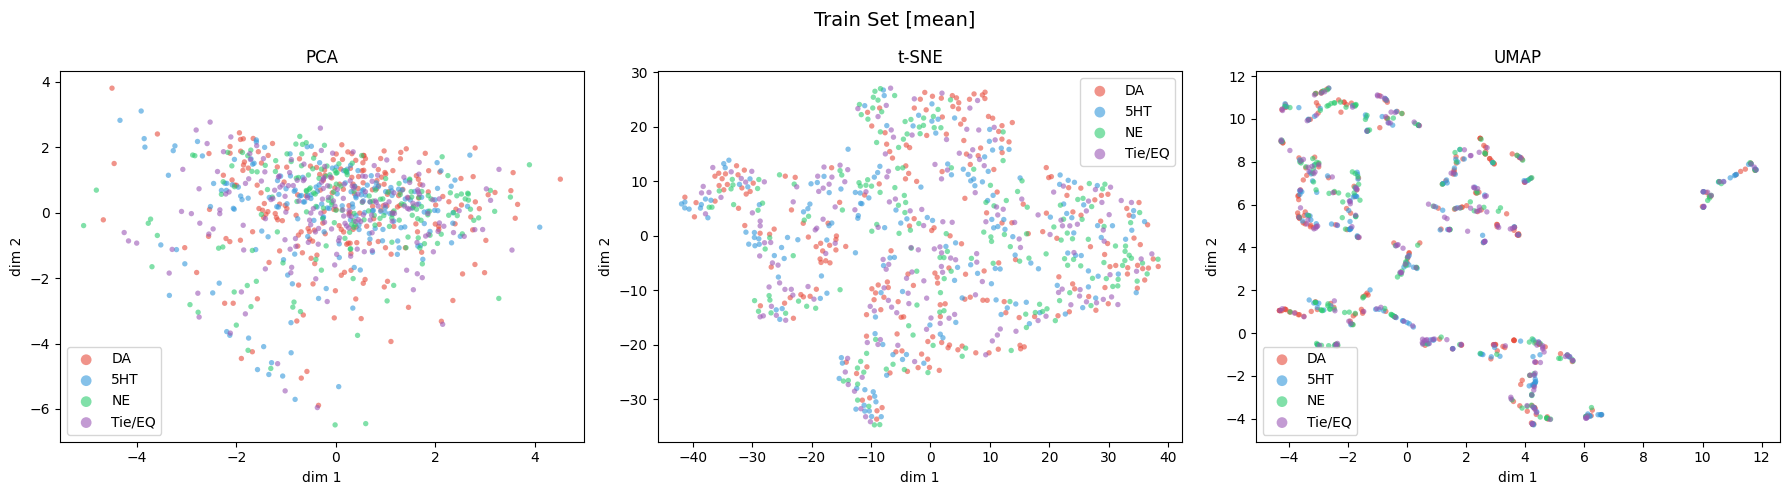

Saved to embeddings_mean.png
Aggregation: 'stats' → feature shape: (768, 240)
Running PCA...
Running t-SNE...
Running UMAP...


/opt/anaconda3/envs/dynamix/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


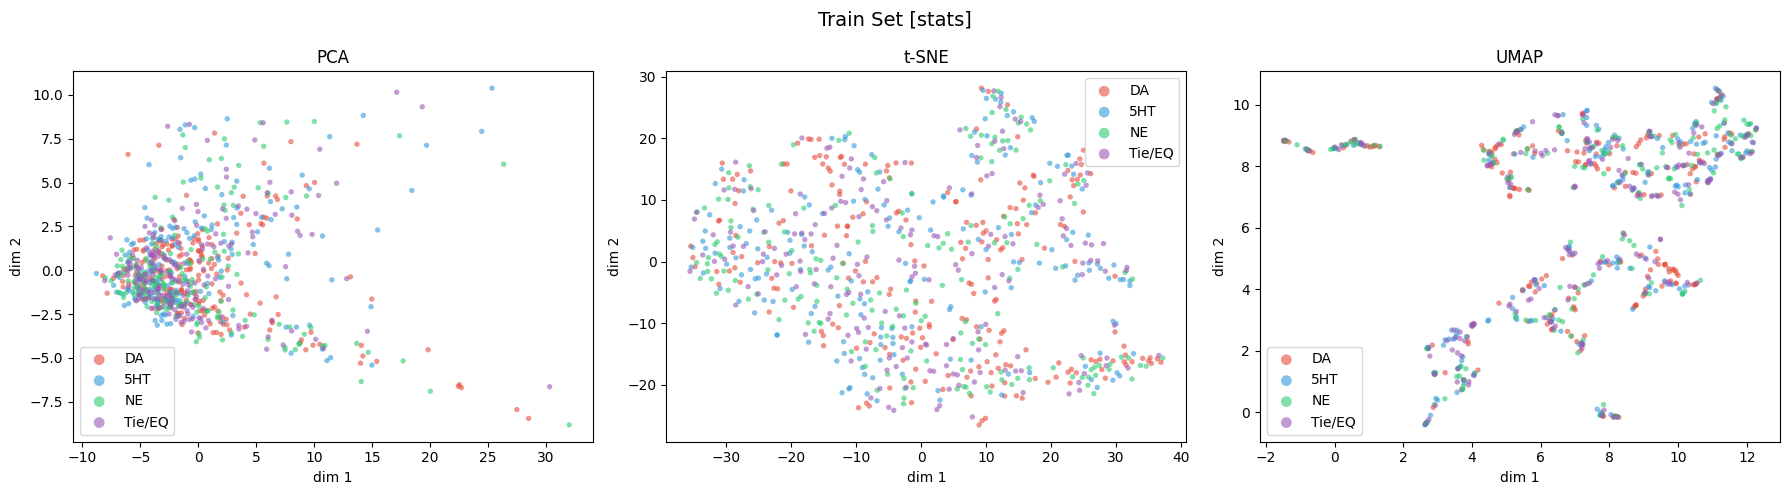

Saved to embeddings_stats.png
Aggregation: 'subsample' → feature shape: (768, 8000)
Running PCA...
Running t-SNE...
Running UMAP...


/opt/anaconda3/envs/dynamix/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


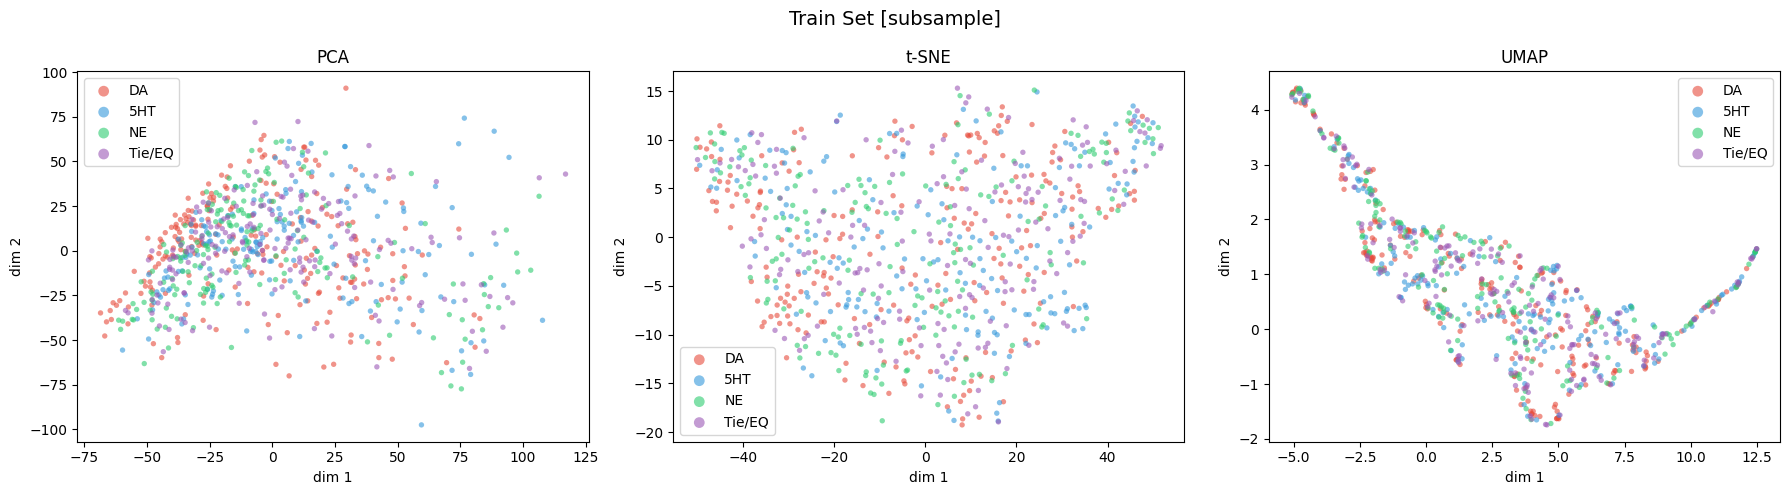

Saved to embeddings_subsample.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

def visualize_embeddings(train_dataloader, title_suffix="Train Set", aggregation="mean"):
    """
    aggregation: "mean"  → mean over time (N, 80)
                 "stats" → concat mean+std+max over time (N, 240)
                 "subsample" → subsample every 10th timestep, flatten (N, 8000)
    """
    # --- Extract data from dataloader ---
    X_all, y_all = [], []
    for X_batch, y_batch in train_dataloader:
        X_all.append(X_batch.numpy())
        y_all.append(y_batch.numpy())
    
    X_raw = np.concatenate(X_all, axis=0)  # (N, 1000, 80)
    y = np.concatenate(y_all, axis=0)      # (N,)

    # --- Time aggregation ---
    if aggregation == "mean":
        X = X_raw.mean(axis=1)                          # (N, 80)
    elif aggregation == "stats":
        X = np.concatenate([
            X_raw.mean(axis=1),
            X_raw.std(axis=1),
            X_raw.max(axis=1),
        ], axis=1)                                       # (N, 240)
    elif aggregation == "subsample":
        X = X_raw[:, ::10, :].reshape(X_raw.shape[0], -1)  # (N, 8000)
    else:
        raise ValueError(f"Unknown aggregation: {aggregation}")

    print(f"Aggregation: '{aggregation}' → feature shape: {X.shape}")

    # --- Dimensionality reduction ---
    print("Running PCA...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    print("Running t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X)

    print("Running UMAP...")
    reducer = umap.UMAP(n_neighbors=5,min_dist=0.01,n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X)

    # --- Plot ---
    class_names = {0: "DA", 1: "5HT", 2: "NE", 3: "Tie/EQ"}
    colors      = {0: "#e74c3c", 1: "#3498db", 2: "#2ecc71", 3: "#9b59b6"}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title_suffix} [{aggregation}]", fontsize=14)

    for ax, (X_emb, name) in zip(axes, [
        (X_pca,  "PCA"),
        (X_tsne, "t-SNE"),
        (X_umap, "UMAP"),
    ]):
        for cls in sorted(np.unique(y)):
            mask = y == cls
            ax.scatter(
                X_emb[mask, 0], X_emb[mask, 1],
                c=colors[int(cls)],
                label=class_names[int(cls)],
                alpha=0.6, s=15, edgecolors='none'
            )
        ax.set_title(name)
        ax.set_xlabel("dim 1")
        ax.set_ylabel("dim 2")
        ax.legend(markerscale=2)

    plt.tight_layout()
    fname = f"embeddings_{aggregation}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved to {fname}")

# Usage — run all three and compare
for agg in ["mean", "stats", "subsample"]:
    visualize_embeddings(train, aggregation=agg)

In [9]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(train[0].reshape(-1, 80000), train[1])

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [10]:
y_pred = svm.predict(test[0].reshape(-1,80000))

In [11]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_true=test[1],y_pred=y_pred))

0.3411214953271028


In [14]:
svm = SVC(kernel='rbf')
svm.fit(np.concatenate([
            train[0].mean(axis=1),
            train[0].std(axis=1),
            train[0].max(axis=1),
        ], axis=1), train[1])
y_pred = svm.predict(np.concatenate([
            test[0].mean(axis=1),
            test[0].std(axis=1),
            test[0].max(axis=1),
        ], axis=1))
print(accuracy_score(y_true=test[1],y_pred=y_pred))

0.308411214953271


In [4]:
from src.reg_models import Regressor, train_regressor, test_regressor
from torch.optim import Adam
from torch import nn

In [5]:
loss = nn.MSELoss()
losses = {}
modes = ['attention', 'mean', 'none']

for mode in modes:
    print("----- Mode: ", mode,"--------")
    model = Regressor(80, 3, pooling=mode)
    optim = Adam(model.parameters(), lr=1e-3)
    train_loss = train_regressor(model=model,train_data_loader=train, val_loader=val,loss=loss,optimizer=optim, device="mps", num_epochs=100)

    losses[mode+" train"] = train_loss
    test_loss = test_regressor(model=model,test_data_loader=test,loss=loss,y_mean=y_mean,y_std=y_std, device='mps')
    losses[mode+" test"] = test_loss


----- Mode:  attention --------
Epoch 10/100| Train Loss: 0.9698| Val Loss: 1.1923
Epoch 20/100| Train Loss: 0.9463| Val Loss: 1.1940
Epoch 30/100| Train Loss: 0.9389| Val Loss: 1.1655
Epoch 40/100| Train Loss: 0.9354| Val Loss: 1.1694
Epoch 50/100| Train Loss: 0.9175| Val Loss: 1.1683
Epoch 60/100| Train Loss: 0.9207| Val Loss: 1.1685
Epoch 70/100| Train Loss: 0.9218| Val Loss: 1.1689
Epoch 80/100| Train Loss: 0.9271| Val Loss: 1.1676
Epoch 90/100| Train Loss: 0.9276| Val Loss: 1.1684
Epoch 100/100| Train Loss: 0.9209| Val Loss: 1.1684
----- Mode:  mean --------
Epoch 10/100| Train Loss: 0.9694| Val Loss: 1.1457
Epoch 20/100| Train Loss: 0.9448| Val Loss: 1.1514
Epoch 30/100| Train Loss: 0.9263| Val Loss: 1.1486
Epoch 40/100| Train Loss: 0.9183| Val Loss: 1.1507
Epoch 50/100| Train Loss: 0.9120| Val Loss: 1.1490
Epoch 60/100| Train Loss: 0.9134| Val Loss: 1.1466
Epoch 70/100| Train Loss: 0.9174| Val Loss: 1.1462
Epoch 80/100| Train Loss: 0.9158| Val Loss: 1.1464
Epoch 90/100| Train Lo

In [6]:
losses["none test"][3].shape
losses["none test"][4].shape


torch.Size([214, 3])

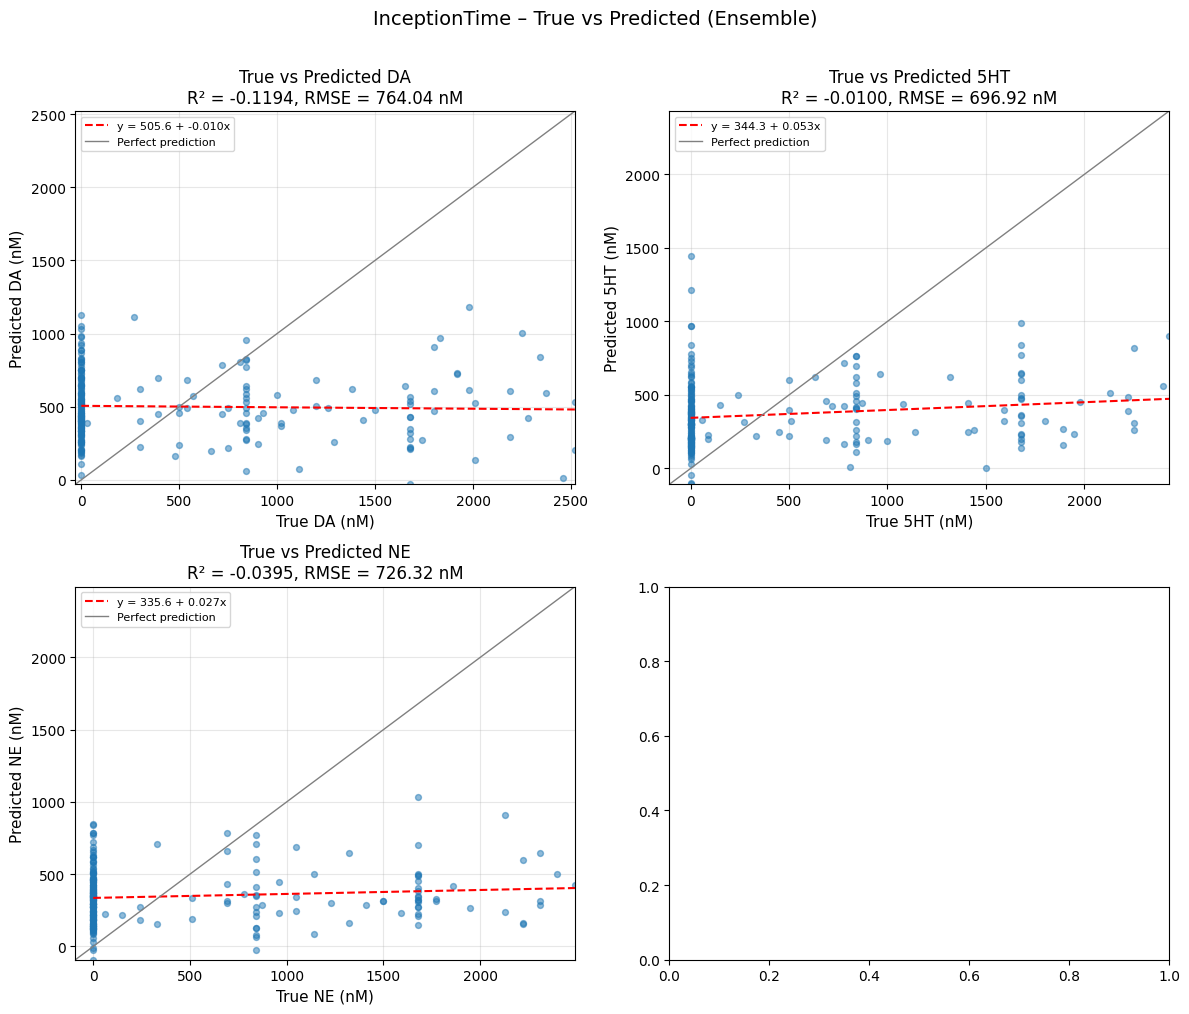

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

ANALYTE_NAMES = ["DA", "5HT", "NE"]
ANALYTE_UNITS = ["nM", "nM", "nM"] 
n_analytes = 3
y_true = losses["none test"][4]
y_pred = losses["none test"][3]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(n_analytes):
    ax = axes[i]
    yt = y_true[:,i].detach().cpu().numpy()
    yp = y_pred[:,i].detach().cpu().numpy()

    # Metrics
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
    rmse = np.sqrt(np.mean((yt - yp) ** 2))

    # Linear fit (regression line) – skip if all true values are identical
    if np.ptp(yt) == 0:
        print(f"WARNING: All true values for {ANALYTE_NAMES[i]} are identical ({yt[0]}). Skipping regression line.")
        slope, intercept = None, None
    else:
        slope, intercept, _, _, _ = stats.linregress(yt, yp)

    # Scatter
    ax.scatter(yt, yp, alpha=0.5, s=18, color="#1f77b4", zorder=2)

    # Regression line
    x_line = np.array([yt.min(), yt.max()])
    if slope is not None:
        ax.plot(x_line, intercept + slope * x_line,
                color="red", linestyle="--", linewidth=1.5,
                label=f"y = {intercept:.1f} + {slope:.3f}x")

    # Perfect prediction line
    all_vals = np.concatenate([yt, yp])
    lim = [all_vals.min(), all_vals.max()]
    ax.plot(lim, lim, color="gray", linewidth=1, label="Perfect prediction")

    unit = ANALYTE_UNITS[i]
    xlabel = f"True {ANALYTE_NAMES[i]}" + (f" ({unit})" if unit else "")
    ylabel = f"Predicted {ANALYTE_NAMES[i]}" + (f" ({unit})" if unit else "")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(
        f"True vs Predicted {ANALYTE_NAMES[i]}\n"
        f"R² = {r2:.4f}, RMSE = {rmse:.2f}" + (f" {unit}" if unit else ""),
        fontsize=12
    )
    ax.legend(fontsize=8)   
    ax.set_xlim(lim); ax.set_ylim(lim)   # optional: comment out for auto-range
    ax.grid(True, alpha=0.3)


plt.suptitle("InceptionTime – True vs Predicted (Ensemble)", fontsize=14, y=1.01)
plt.tight_layout()
#plt.savefig("Ensemble_inception_true_vs_pred.png", dpi=150, bbox_inches="tight")
#print("Saved → inception_true_vs_pred.png")
plt.show()
#input for each TRY
#start with 1 probe